## <u>Import Libraries</u>

In [1]:
import pandas as pd
import numpy as np
import re  # regex, for text cleaning
import nltk # Natural Language Tool Kit
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
from torch.utils.data import random_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

[nltk_data] Downloading package punkt to /Users/apple/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/apple/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/apple/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## <u>Load Dataset</u>

In [2]:
data = pd.read_csv("IMDB Dataset.csv")
print("Shape with duplicates : ",data.shape)
data.drop_duplicates(inplace = True) # inplace = True makes changes in the orginal dataframe
print("Shape without duplicates : ", data.shape)
print(data["review"].str.split().str.len().describe()) # .split makes tokens, .len counts tokens in a line, describe runs the math
data.head()

Shape with duplicates :  (50000, 2)
Shape without duplicates :  (49582, 2)
count    49582.000000
mean       231.350167
std        171.542020
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: review, dtype: float64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


---
## <u>Text Preprocessing: worked example</u>

Every cleaning step below is shown on one real sentence first, so the transformation is visible before applying it to all ~49,000 reviews.

> "Fight Club is a really, really good movie. It's a slow burner, but the last 30 minutes of the movie are fabulous with one of the best plot twists in cinema history."

Six steps: lowercase, remove HTML, remove URLs, remove punctuation, remove stopwords, stemming.

### Step 1: lowercase

```
fight club is a really, really good movie. it's a slow burner, but the last 30
minutes of the movie are fabulous with one of the best plot twists in cinema history.
```

In [3]:
data["review"] = data["review"].str.lower()
data["review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production. <br /><br />the...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: review, dtype: object

### Step 2: remove HTML

This step runs **before** punctuation removal deliberately. Punctuation removal strips `<`/`>`, and by the time HTML removal would look for `<tag>` patterns, there would be nothing left to find. This example has no HTML tags, so it passes through unchanged here, but IMDB reviews often contain `<br /><br />` line breaks, which this step is for.

In [4]:
def remove_html(text):
    text = re.sub(r"<.*?>", "", text) # . = any character, * = 0 or more, ? = non-greedy
    return text

data["review"] = data["review"].apply(remove_html)
data["review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production. the filming tec...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: review, dtype: object

### Step 3: remove URLs

No URLs in this example either, but the same principle applies dataset wide.

In [5]:
def remove_urls(text):
    text = re.sub(r"http\S+","",text) # \S+ = one or more non-whitespace characters (the whole URL)
    return text

data["review"] = data["review"].apply(remove_urls)
data["review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production. the filming tec...
2    i thought this was a wonderful way to spend ti...
3    basically there's a family where a little boy ...
4    petter mattei's "love in the time of money" is...
Name: review, dtype: object

### Step 4: remove punctuation

```
fight club is a really really good movie its a slow burner but the last 30
minutes of the movie are fabulous with one of the best plot twists in cinema history
```
Commas, the period, and the apostrophe in "it's" are gone. `it's` becomes `its`.

In [6]:
def remove_punc(text):
    text = re.sub(r"[^A-Za-z0-9\s]", "", text) # \s = single whitespace character, fixed: stray "-" was in the allowed set,
    return text                                 # ^ means exclude everything in this set which kept hyphens instead of stripping them

data["review"] = data["review"].apply(remove_punc)
data["review"].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically theres a family where a little boy j...
4    petter matteis love in the time of money is a ...
Name: review, dtype: object

### Step 5: remove stopwords

Tokenize first, then drop common low-meaning words (`is`, `a`, `its`, `but`, `the`, `of`, `are`, `with`, `in`). 32 tokens become 19:
```
['fight','club','really','really','good','movie','slow','burner','last','30',
 'minutes','movie','fabulous','one','best','plot','twists','cinema','history']
```

In [7]:
def remove_stop_words(text):
    tokens = word_tokenize(text)
    stop_words = stopwords.words("english")
    filtered_tokens = []                   # will hold only the tokens we want to KEEP (non-stopwords)

    for token in tokens:
        if token not in stop_words:       # keep the token only if it's NOT a stopword
            filtered_tokens.append(token)

    # " " is the string separator we want to insert between each item
    # .join() that takes all the items in the list and glues them together using the separator string
    return " ".join(filtered_tokens)

data["review"] = data["review"].apply(remove_stop_words)
data["review"].head()

0    one reviewers mentioned watching 1 oz episode ...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically theres family little boy jake thinks...
4    petter matteis love time money visually stunni...
Name: review, dtype: object

### Step 6: stemming

Porter Stemmer reduces words to a rough base form, not always a real word, and that is expected. Still 19 tokens, several change:
```
['fight','club','realli','realli','good','movi','slow','burner','last','30',
 'minut','movi','fabul','one','best','plot','twist','cinema','histori']
```
`really` becomes `realli`, `movie` becomes `movi`, `minutes` becomes `minut`, `fabulous` becomes `fabul`, `twists` becomes `twist`, `history` becomes `histori`. The point is not readability: `movie` and `movies` both collapse to `movi`, so the model treats them as the same word.

In [8]:
def stemming(text):
    tokens = word_tokenize(text)
    ps = PorterStemmer()
    stemmed_words = []

    for token in tokens:
        stemmed_token = ps.stem(token)      # .stem() takes ONE string at a time
        stemmed_words.append(stemmed_token)

    return " ".join(stemmed_words)

data["review"] = data["review"].apply(stemming)
data["review"].head()

0    one review mention watch 1 oz episod youll hoo...
1    wonder littl product film techniqu unassum old...
2    thought wonder way spend time hot summer weeke...
3    basic there famili littl boy jake think there ...
4    petter mattei love time money visual stun film...
Name: review, dtype: object

---
## <u>Encoding Labels</u>

In [9]:
le = LabelEncoder()
y = le.fit_transform(data["sentiment"])
type(y)

numpy.ndarray

---
## <u>Train Test Split: before building the vocabulary</u>

Same leakage principle as scaling and imputation on tabular data: the vocabulary should only be built from words the model would realistically have seen during training. Splitting **before** vocabulary building means the vocabulary never sees test set only words.

In [10]:
X_train_text, X_test_text, y_train, y_test = train_test_split( # using X_train_text and X_test_text here as we will need to make a new X_train/X_test later from these
    data["review"],
    y,
    test_size=0.2,
    random_state=42
)

---
## <u>Build Vocabulary: worked example</u>

vectorization is the general umbrella term for turning text into numbers at all. Bag of Words, TF-IDF, and embeddings are all forms of vectorization. Embedding specifically means a *dense, learned* vector, as opposed to BoW/TF-IDF's *sparse, counted* vectors. Embeddings are a type of vectorization, not a separate unrelated thing.

In the real pipeline, the vocabulary is built by counting every word across **all training reviews** and keeping the most frequent `vocab_size` of them. For illustration, here is the toy vocabulary the cleaned and stemmed example sentence would produce on its own (17 unique words plus 2 reserved slots):

```
0 = <PAD>      (padding filler)
1 = <UNK>      (a word not in the dictionary)
2 = fight    3 = club     4 = realli   5 = good     6 = movi
7 = slow     8 = burner   9 = last     10 = 30      11 = minut
12 = fabul   13 = one     14 = best    15 = plot    16 = twist
17 = cinema  18 = histori
```

The real vocabulary (below) works identically, just built from ~40,000 reviews instead of one sentence, and kept to the 5000 most frequent words.

In [11]:
def build_vocabulary(text, vocab_size = 5000):
    all_tokens = [] # collect every single token from every single review, duplicates included, we need the duplicates for counting frequency

    for review in text:
        # text here is the whole X_train_text Series, so we loop through it ourselves, one review at a time
        # word_tokenize breaks ONE review into a list of word tokens, .extend adds each word as its own item into all_tokens
        # (unlike .append, which would add the whole list as one nested item)
        all_tokens.extend(word_tokenize(review))

    # Counter walks through all_tokens and tallies how many times each unique word appears
    # returns something like Counter({"movie": 15234, "good": 8901, ...})
    token_counts = Counter(all_tokens)

    # customizing the dictionary ourselves, so the first 2 slots are hardcoded rather than earned by frequency
    # <PAD> = padding filler for short reviews, <UNK> = fallback for a word not in our vocabulary
    token_to_index = {
        "<PAD>" : 0,
        "<UNK>" : 1
    }

    # .most_common(n) returns the top n most frequent (word, count) pairs, sorted highest-first, as a list of tuples
    # vocab_size - 2 because indices 0 and 1 are already reserved for <PAD> and <UNK>
    most_common_tokens = token_counts.most_common(vocab_size - 2)

    # enumerate hands us a running index (starting at 2, since 0/1 are taken) alongside each (token, count) pair
    # count itself is not used here, it only mattered for sorting inside most_common(), not for building the dictionary
    for index, (token, counts) in enumerate(most_common_tokens, start = 2):
        token_to_index[token] = index

    return token_to_index

# fit only on X_train_text, never on test data, so the vocabulary never sees test-only words (the leakage principle from the markdown above)
word_to_index = build_vocabulary(X_train_text, vocab_size = 5000)

---
## <u>Encode and Pad Reviews: worked example</u>

Two things happen to every review. First, each cleaned word is replaced with its vocabulary index. Second, every review is padded or truncated to the same fixed length so batches can be stacked into one rectangular tensor.

Using the toy vocabulary above, the example sentence's 19 cleaned tokens become:
```
[2, 3, 4, 4, 5, 6, 7, 8, 9, 10, 11, 6, 12, 13, 14, 15, 16, 17, 18]
```
With `max_len=20`, one `0` (`<PAD>`) is appended to reach the fixed length:
```
[2, 3, 4, 4, 5, 6, 7, 8, 9, 10, 11, 6, 12, 13, 14, 15, 16, 17, 18, 0]
```
A shorter review gets more `0`s appended. A longer one gets cut off at position 20.

**Choosing `max_len` for the real data:** the review length stats from the Load Dataset step showed a median of 173 words and a 75th percentile of 281, right skewed, with a long tail up to 2470. `max_len=250` covers the large majority of reviews in full while not forcing every batch to pad out to an extreme outlier's length.

In [12]:
def encode_review(text, word_to_index, max_length):
    # tokenize ONE review string into its individual words
    tokens = word_tokenize(text)

    indices = []
    for token in tokens:
        if token in word_to_index:
            indices.append(word_to_index[token]) # word is known, use its vocabulary index
        else:
            indices.append(1)                    # word is not in our vocabulary, fall back to <UNK> (index 1)

    # pad short reviews with 0s (<PAD>) up to max_length, or cut long reviews down to max_length
    if len(indices) < max_length:
        indices = indices + [0] * (max_length - len(indices))
    else:
        indices = indices[:max_length]

    return indices

# apply encode_review to every review individually, building up one list of encoded reviews at a time
# encode_review only handles ONE review, so we loop through X_train_text/X_test_text ourselves, same reasoning as build_vocabulary
X_train = []
for review in X_train_text:
    encoded_review = encode_review(review, word_to_index, 250)
    X_train.append(encoded_review)

X_test = []
for review in X_test_text:
    encoded_review = encode_review(review, word_to_index, 250)
    X_test.append(encoded_review)

# wrap both as DataFrames so .values gives a clean 2D array for the tensor conversion step ahead
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,240,241,242,243,244,245,246,247,248,249
0,16,5,2,1,86,1,12,5,47,286,...,0,0,0,0,0,0,0,0,0,0
1,301,12,2,601,1,2,56,106,150,384,...,0,0,0,0,0,0,0,0,0,0
2,201,39,26,528,1,3,37,131,808,1,...,122,1710,808,2138,349,0,0,0,0,0
3,820,797,51,165,180,704,1877,25,820,494,...,0,0,0,0,0,0,0,0,0,0
4,113,454,1668,250,1,1483,1,855,889,4638,...,1,1,81,1,190,1,3602,1,3331,1359


---
## <u>Dataset and DataLoader</u>

In [13]:
# nn.Embedding needs integer indices (LongTensor) to look up rows in its table, not floats, so dtype=torch.int64
# X_train/X_test are DataFrames here, .values strips the pandas wrapper down to a raw numpy array first
X_train_tensor = torch.tensor(X_train.values, dtype = torch.int64)
X_test_tensor = torch.tensor(X_test.values, dtype = torch.int64)

# y_train/y_test are already plain numpy arrays (from LabelEncoder), so no .values needed here
# float32 to match BCEWithLogitsLoss's expectations, .view(-1,1) reshapes (n,) into (n,1) to match the model's single output neuron
y_train_tensor = torch.tensor(y_train, dtype = torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test, dtype = torch.float32).view(-1,1)

train_set = TensorDataset(X_train_tensor, y_train_tensor)
test_set = TensorDataset(X_test_tensor, y_test_tensor)  # untouched by the split below, stays the genuine held-out set

# carving a validation set out of the training data itself, not out of test_set
# this is what decides checkpointing during training, so test_set can stay fully unseen until the very end
train_set, val_set = random_split(
    train_set,
    [0.85,0.15],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)  # carved from training data, used for checkpointing
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)  # only ever touched once, at final evaluation

---
## <u>Model Architecture</u>

This is a many to one architecture: it reads an entire sequence and produces a single output at the end, one sentiment prediction per review.

`nn.Embedding` turns each word-index integer into a learned vector (`embedding_dim` numbers, 100 here). This is what gives the RNN a genuine sequence to process, timestep by timestep, instead of one collapsed vector.

Plain `nn.RNN` here, one state only, the hidden state, unlike LSTM's hidden state plus cell state pair. `h0` still needs its own zero-initialized starting tensor, same as every RNN built so far, but there is only one of it to create and only one returned at the end, not a pair.

Shape journey (batch_size=64, vocab_size=5000, max_len=250, embedding_dim=100, hidden_size=128):
```
(64, 250)              64 reviews, 250 word-index integers each, in order
      |
      | nn.Embedding
      v
(64, 250, 100)          64 reviews, 250 real word-vectors each: goes into the RNN
      |
      | self.rnn(x, h0), h0 shape (1, 64, 128)
      v
out:  (64, 250, 128)     hidden state at every one of the 250 timesteps
hn:   (1, 64, 128)       hidden state at only the final timestep: this is what gets kept
      |
      | hn[-1]
      v
(64, 128)                last layer's final hidden state
      |
      | dropout(0.2), then self.fc: Linear(128 -> 1)
      v
(64, 1)                  final prediction per review
```

Dropout (0.2) sits inside `self.fc`, right before the linear layer, same place dropout went in the earlier tabular builds.

In [16]:
class RNN(nn.Module):

    def __init__(self, vocab_size, embedding_dim = 100, hidden_size = 128, num_layers = 2):
        super(RNN, self).__init__()

        # saving these so forward() can use them later
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # lookup table: vocab_size rows tall, embedding_dim columns wide, turns a word-index integer into a learned vector
        # padding_idx=0 tells PyTorch index 0 (<PAD>) doesn't need a meaningful, trainable vector
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx = 0)

        # nn.RNN takes (input_size, hidden_size, num_layers) -- vocab_size does NOT belong here,
        # it was accidentally passed in as a 4th positional argument before, which shifted hidden_size and num_layers
        # into the wrong slots and pushed num_layers into nonlinearity's position (which expects 'tanh'/'relu', not a number)
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first = True)

        # 1 output neuron, binary sentiment, no activation here, BCEWithLogitsLoss applies sigmoid internally
        # dropout sits right before the final linear layer, same spot as every prior build
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 1)
        )

    def forward(self,x):
        # (batch, 250) word-indices -> (batch, 250, embedding_dim) real word-vectors
        x_embed = self.embedding(x)

        # blank starting memory, shape (num_layers, batch_size, hidden_size)
        hidden_state_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # rnn reads the review 250 words at a time, timestep_history holds every step's hidden state (not needed here)
        # final_timestep holds only the LAST timestep's hidden state, across all layers, shape (num_layers, batch, hidden_size)
        timestep_history, final_timestep = self.rnn(x_embed, hidden_state_0)

        # [-1] grabs the deepest (last) layer's final hidden state and drops the num_layers dimension, leaving (batch, hidden_size)
        x_fc = self.fc(final_timestep[-1])

        return x_fc

---
## <u>Compile the Model</u>

Three things needed here, same pattern as every prior build.

Instantiate the model: `RNN(vocab_size)`. `vocab_size` comes from `len(word_to_index)`, not a hardcoded number, since it has to match the actual dictionary built earlier, including the `<PAD>` and `<UNK>` slots.

Loss function: `nn.BCEWithLogitsLoss()`. Binary sentiment (positive/negative), 1 output neuron, no activation on `fc`, sigmoid is applied internally by this loss function, same convention as the UFC and cat/dog binary builds.

Optimizer: `optim.Adam(model.parameters())`, same as every other build so far.

In [17]:
model = RNN(len(word_to_index))

loss_func = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

Same skeleton as the tabular ANN builds. The only genuinely new thing here is what comes out of the `DataLoader` each iteration.

Outer loop over epochs, `train_loss_history` and `val_loss_history` lists, `best_val_loss = float("inf")`, `best_epoch` tracker: identical to every previous project.

`model.train()` before the batch loop, `model.eval()` plus `torch.no_grad()` before the validation loop: identical.

Inner batch loop: `for x_batch, y_batch in train_loader:`. `x_batch` here is shape `(64, 250)`, word-index integers. `y_batch` is shape `(64, 1)`, float 0/1 labels. Nothing extra needed to prep them, the embedding lookup happens inside `forward()`, not out here.

`optimizer.zero_grad()`, then `model(x_batch)`, then `loss_func(y_pred, y_batch)`, then `.backward()`, then `.step()`: identical five step sequence to every build so far.

Accumulate `total_train_loss`, divide by `len(train_loader)` at the end of each epoch: identical reasoning to before, average of per-batch averages.

Validation loop, same structure, over `test_loader` instead.

Checkpoint: `if avg_val_loss < best_val_loss:` then save `model.state_dict()` and track `best_epoch`.

Watch the printed loss each epoch closely here. If training loss sits near `0.693` (`-ln(0.5)`, the loss value for a coin flip) and barely moves across all 40 epochs, that is the signature covered in the LSTM notes: gradients not flowing back far enough through 250 timesteps for the network to learn anything, not a bug in this code.

In [18]:
epochs = 40
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 1

for epoch in range(epochs):

    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_pred_tensor = model(x_batch)
        batch_loss = loss_func(y_pred_tensor, y_batch)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            y_pred_tensor = model(x_batch)
            batch_loss = loss_func(y_pred_tensor, y_batch)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)  
    val_loss_history.append(avg_val_loss)

    print(f"epoch {epoch+1}/{epochs} ----------> training loss = {avg_train_loss} -----------> validation loss = {avg_val_loss}")

    if best_val_loss > avg_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_rnn_model.pt")
        best_epoch = epoch + 1

print(f"best model at epoch : {best_epoch}")

epoch 1/40 ----------> training loss = 0.6945308595895767 -----------> validation loss = 0.6932425761735568
epoch 2/40 ----------> training loss = 0.6922936480153691 -----------> validation loss = 0.6927034431888212
epoch 3/40 ----------> training loss = 0.6922421943057667 -----------> validation loss = 0.6941361478579942
epoch 4/40 ----------> training loss = 0.6932123671426917 -----------> validation loss = 0.693089529391258
epoch 5/40 ----------> training loss = 0.6939771405675195 -----------> validation loss = 0.6953156148233721
epoch 6/40 ----------> training loss = 0.6933098117058928 -----------> validation loss = 0.7029382182705787
epoch 7/40 ----------> training loss = 0.6947828517718748 -----------> validation loss = 0.6932334361537811
epoch 8/40 ----------> training loss = 0.6945735308708567 -----------> validation loss = 0.6938178955867726
epoch 9/40 ----------> training loss = 0.694147625655839 -----------> validation loss = 0.6933072497767787
epoch 10/40 ----------> traini

---
## <u>Plot the Loss Curves</u>

Same as every prior build: `train_loss_history` and `val_loss_history` into a small DataFrame, then `plt.plot(...)`, training vs validation loss, labeled axes, legend.

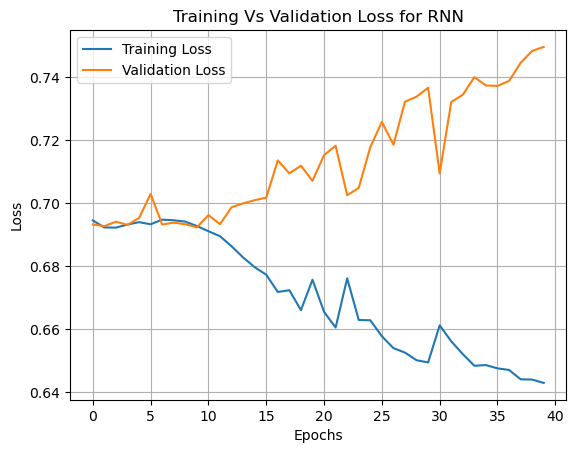

In [19]:
df_loss = pd.DataFrame({
    "Training loss" : train_loss_history,
    "Validation loss" : val_loss_history
})

plt.plot(df_loss["Training loss"], label="Training Loss")
plt.plot(df_loss["Validation loss"], label="Validation Loss")

plt.title("Training Vs Validation Loss for RNN")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint and Evaluate</u>

Load the checkpoint: `model.load_state_dict(torch.load(...))`, then `model.eval()` so dropout is switched off during evaluation.

Getting predictions follows the cat/dog CNN pattern, not the tabular one. The test set here (~10,000 reviews, each `(250,)` word indices, run through an embedding and an RNN) is heavier per sample than tabular data, closer in spirit to the image case than to DateFruit's single-shot approach. This uses the same batch-accumulated evaluation pattern as CIFAR10 and cat/dog: loop over `test_loader` (and `train_loader`, to get both sets of metrics), collect predictions and labels batch by batch, `torch.cat` them together, compute metrics once on the full set.

Binary decision, not `argmax`: same reasoning as every binary build, 1 output neuron, so `torch.sigmoid(logits)` then `(probs >= 0.5).float()`.

Metrics: `accuracy_score`, `precision_score`, `recall_score`, `f1_score` on the concatenated predictions vs labels. No `average=` parameter needed since this is binary, not multiclass.

`all_test_preds.unique(return_counts=True)` right after is the actual diagnostic worth reading carefully: if nearly every prediction lands on one class, that confirms the model has collapsed rather than learned anything real, the same signature as accuracy sitting at the baseline rate with recall near 1 and precision near the baseline rate.

In [20]:
model.load_state_dict(torch.load("best_rnn_model.pt", weights_only = True))

model.eval()

# predictions
all_train_preds = []
all_test_preds = []

# answers
all_train_labels = []
all_test_labels = []

with torch.no_grad():
    for x_train_batch, y_train_batch in train_loader:

        y_pred_train_tensor = model(x_train_batch)                                  # raw logit
        train_probabilities = torch.sigmoid(y_pred_train_tensor)                    # turn raw logits into probabilities
        pred_train_classes = (train_probabilities >= 0.5).float()                   # turn probabilities into 0/1 predicted classes

        all_train_preds.append(pred_train_classes)
        all_train_labels.append(y_train_batch)

    for x_test_batch, y_test_batch in test_loader:

        y_pred_test_tensor = model(x_test_batch)
        test_probabilities = torch.sigmoid(y_pred_test_tensor)
        pred_test_classes = (test_probabilities >= 0.5).float()

        all_test_preds.append(pred_test_classes)
        all_test_labels.append(y_test_batch)

# concatenation
all_train_preds = torch.cat(all_train_preds)
all_test_preds = torch.cat(all_test_preds)
all_train_labels = torch.cat(all_train_labels)
all_test_labels = torch.cat(all_test_labels)

# evaluation
print("For Training:-")
print(f"Accuracy Score : {accuracy_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"Precision Score : {precision_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"Recall Score : {recall_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"F1 Score : {f1_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print("\n")
print("For Testing:-")
print(f"Accuracy Score : {accuracy_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"Precision Score : {precision_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"Recall Score : {recall_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"F1 Score : {f1_score(all_test_labels.numpy(), all_test_preds.numpy())}")

For Training:-
Accuracy Score : 0.5218590580139992
Precision Score : 0.5236389264109943
Recall Score : 0.5267635590216235
F1 Score : 0.5251965952934939


For Testing:-
Accuracy Score : 0.5043864071795906
Precision Score : 0.5063316582914573
Recall Score : 0.5060265166733628
F1 Score : 0.5061790414950266


In [21]:
all_test_preds.unique(return_counts=True)

(tensor([0., 1.]), tensor([4942, 4975]))

---
## <u>Why This Does Not Work</u>

Expect training loss to sit near `0.693` (`-ln(0.5)`, the loss for a coin flip) for most or all of the 40 epochs, barely moving. Test accuracy should land close to 50%, and `all_test_preds.unique(return_counts=True)` above should show almost every prediction landing on one single class rather than a genuine mix.

That combination, accuracy at the baseline rate, recall near 1, precision near the baseline rate, is the fingerprint of a model that has collapsed to predicting roughly the same answer every time, rather than one that failed to reach high accuracy despite trying.

The cause is the vanishing gradient problem. A plain RNN rewrites its hidden state completely at every timestep through a nonlinear function (`tanh(Wx + Uh + b)`), no "leave it mostly alone" option. Backpropagating a gradient through 250 of these rewrites in a row shrinks it multiplicatively at each step, and by the time the gradient reaches the earliest timesteps it is effectively zero. The network cannot learn from most of a 250 word review, so it settles for the lowest effort solution available: guess roughly the same class every time.

This is not a bug to fix in this file. It is the reason LSTM exists. The fix, the hidden state plus cell state split and the forget/input/output gates, is worked through in the LSTM notes, and the working version of this exact sentiment classifier lives in `minor-project/lstm-sentiment/`, same pipeline, same architecture shape, one layer swapped.